<a href="https://colab.research.google.com/github/lgplorea/EjerciciosPython/blob/main/statsAguacate2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- Configuración del Rango Comercial ---
Introduce el peso MÍNIMO ideal (en gramos): 400
Introduce el peso MÁXIMO ideal (en gramos): 600
Analisis de la cosecha de aguacates
Peso promedio:  470.00 gramos
Peso central: 482.5 gramos
Peso más común: 490 gramos
Desviación estándar:  90.09 gramos
Coeficiente de variación:  19.17%
Peso más pesado: 610 gramos
Peso más ligero: 315 gramos
Rango de pesos: 295 gramos
Aguacates en rango ideal: 8
Asimetría: 0.059914435115694574, asimetria Positiva (cola a la derecha)


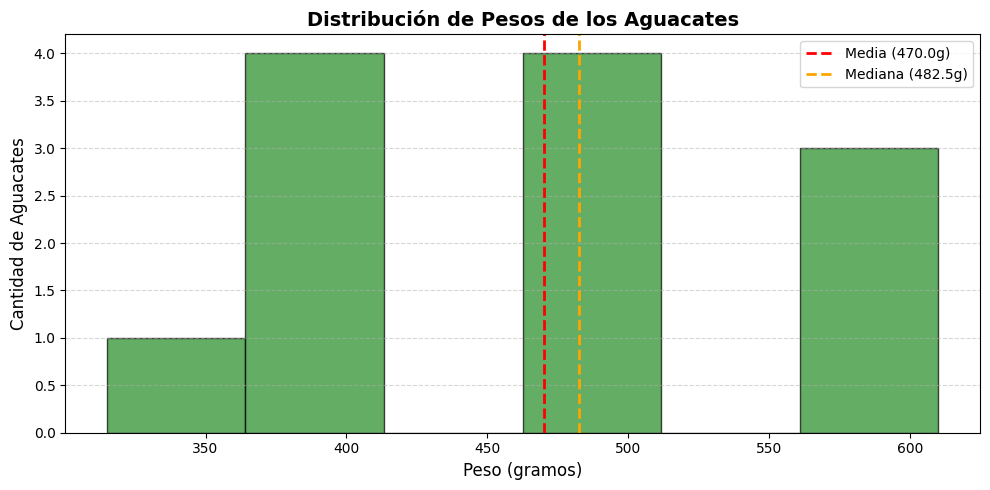

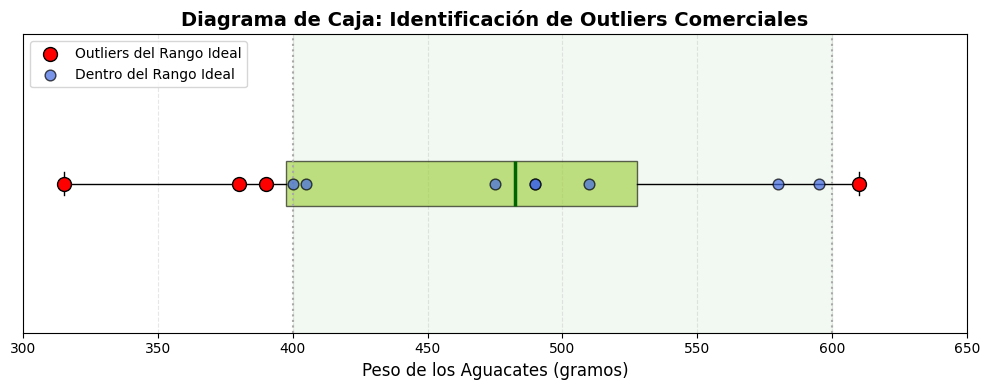

¡Reporte generado con éxito!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
import numpy as np
import statistics as stats
import matplotlib.pyplot as plt
import pandas as pd

#Pesos de los aguacates en gramos
aguacate = [400, 580, 390, 610, 475, 490, 595, 315, 490, 380, 510, 405]

#Estadísticas descriptivas
media = np.mean(aguacate) # promedio
mediana = np.median(aguacate) # valor central
moda = stats.mode(aguacate) # valor más común
desviacion = np.std(aguacate) # la variabilidad de los pesos
cv = (desviacion / media) * 100 # Coeficiente de Variación (en porcentaje)
mas_pesada = max(aguacate)    # El valor más alto
mas_ligera = min(aguacate)    # El valor más bajo
rango = mas_pesada - mas_ligera # La diferencia total

print("\n--- Configuración del Rango Comercial ---")
# Solicitamos los límites al usuario y los convertimos a enteros
rango_min = int(input("Introduce el peso MÍNIMO ideal (en gramos): "))
rango_max = int(input("Introduce el peso MÁXIMO ideal (en gramos): "))

# Convertimos la lista a un array de Numpy
aguacate_np = np.array(aguacate)

# Creamos la condición dinámica usando las variables del usuario
dentro_del_rango = (aguacate_np >= rango_min) & (aguacate_np <= rango_max)

# np.sum contará cuántos True hay en la condición
total_ideal = np.sum(dentro_del_rango)

# --- CÁLCULO DE LA ASIMETRÍA MANUAL CON NUMPY ---
# 1. Calculamos la diferencia de cada dato respecto a la media y lo elevamos al cubo
cubos_desviacion = (aguacate_np - media) ** 3

# 2. Aplicamos la fórmula (promedio de los cubos dividido entre la desviación al cubo)
asimetria = np.mean(cubos_desviacion) / (desviacion ** 3)

# Interpretación
if asimetria > 0:
    tipo_asimetria = "Positiva (cola a la derecha)"
elif asimetria < 0:
    tipo_asimetria = "Negativa (cola a la izquierda)"
else:
    tipo_asimetria = "Simétrica"

#Resultados
print(f"Analisis de la cosecha de aguacates")
print(f"Peso promedio: {media: .2f} gramos")
print(f"Peso central: {mediana} gramos")
print(f"Peso más común: {moda} gramos")
print(f"Desviación estándar: {desviacion: .2f} gramos")
print(f"Coeficiente de variación: {cv: .2f}%")
print(f"Peso más pesado: {mas_pesada} gramos")
print(f"Peso más ligero: {mas_ligera} gramos")
print(f"Rango de pesos: {rango} gramos")
print(f"Aguacates en rango ideal: {total_ideal}")
print(f"Asimetría: {asimetria}, asimetria {tipo_asimetria}")

#HISTOGRAMA DE DISTRIBUCION DE PESOS
plt.figure(figsize=(10, 5)) # Define el tamaño de la ventana (ancho, alto)

# Creamos el histograma
# 'bins' define cuántas barras queremos. Al ser 12 datos, 5 o 6 barras está bien.
plt.hist(aguacate, bins=6, color='forestgreen', edgecolor='black', alpha=0.7)

# Añadimos líneas de referencia útiles
plt.axvline(media, color='red', linestyle='dashed', linewidth=2, label=f'Media ({media:.1f}g)')
plt.axvline(mediana, color='orange', linestyle='dashed', linewidth=2, label=f'Mediana ({mediana:.1f}g)')

# Títulos y etiquetas
plt.title('Distribución de Pesos de los Aguacates', fontsize=14, fontweight='bold')
plt.xlabel('Peso (gramos)', fontsize=12)
plt.ylabel('Cantidad de Aguacates', fontsize=12)
plt.legend() # Muestra la leyenda de la media y mediana
plt.grid(axis='y', linestyle='--', alpha=0.5) # Cuadrícula de fondo solo horizontal

plt.tight_layout() # Ajusta los márgenes automáticamente
plt.show() # Muestra la gráfica en pantalla

#GRÁFICA DE CAJA (BOXPLOT) PARA VISUALIZAR VALORES ATÍPICOS (OUTLIERS)
plt.figure(figsize=(10, 4))

# 1. Dibujamos el boxplot base de forma horizontal
# Desactivamos 'showfliers' para que no pinte los atípicos estadísticos por defecto
plt.boxplot(aguacate, vert=False, patch_artist=True,
            boxprops=dict(facecolor='yellowgreen', color='black', alpha=0.6),
            whiskerprops=dict(color='black'),
            capprops=dict(color='black'),
            medianprops=dict(color='darkgreen', linewidth=2.5),
            showfliers=False)

# 2. Filtramos los aguacates que están fuera del rango ideal usando la condición invertida (~)
fuera_de_rango = aguacate_np[~dentro_del_rango]

# 3. Dibujamos los outliers comerciales uno por uno como puntos rojos
# Usamos [1] * len(...) para alinearlos exactamente a la altura del boxplot
plt.scatter(fuera_de_rango, [1] * len(fuera_de_rango),
            color='red', edgecolor='black', s=100, zorder=3,
            label='Outliers del Rango Ideal')

# 4. Dibujamos también los aguacates aprobados (dentro del rango) en azul para contrastar
dentro_de_rango = aguacate_np[dentro_del_rango]
plt.scatter(dentro_de_rango, [1] * len(dentro_de_rango),
            color='royalblue', edgecolor='black', s=60, alpha=0.7, zorder=3,
            label='Dentro del Rango Ideal')

# --- Detalles visuales para identificar el rango comercial ---
plt.axvline(400, color='darkgray', linestyle=':', linewidth=1.5)
plt.axvline(600, color='darkgray', linestyle=':', linewidth=1.5)
# Sombreado sutil que delimita la zona ideal en el fondo
plt.axvspan(400, 600, color='green', alpha=0.05)

# Títulos y personalización de la gráfica
plt.title('Diagrama de Caja: Identificación de Outliers Comerciales', fontsize=14, fontweight='bold')
plt.xlabel('Peso de los Aguacates (gramos)', fontsize=12)
plt.yticks([]) # Ocultamos las etiquetas del eje Y ya que solo es una dimensión
plt.xlim(300, 650) # Ajustamos los márgenes del eje X para que los puntos no queden pegados al borde
plt.legend(loc='upper left')
plt.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

from google.colab import files

# 1. Abrimos el archivo txt en modo escritura ('w') y guardamos el reporte
with open("reporte_aguacates.txt", "w") as f:
    f.write("--- REPORTES DE LA COSECHA DE AGUACATES ---\n")
    f.write(f"Peso promedio: {media:.2f} gramos\n")
    f.write(f"Peso central: {mediana} gramos\n")
    f.write(f"Peso más común: {moda} gramos\n")
    f.write(f"Desviación estándar: {desviacion:.2f} gramos\n")
    f.write(f"Coeficiente de variación: {cv:.2f}%\n")
    f.write(f"Peso más pesado: {mas_pesada} gramos\n")
    f.write(f"Peso más ligero: {mas_ligera} gramos\n")
    f.write(f"Rango de pesos: {rango} gramos\n")
    f.write(f"Asimetría de los datos: {asimetria:.4f} ({tipo_asimetria})\n")
    f.write(f"Aguacates en rango ideal ({rango_min}g - {rango_max}g): {total_ideal}\n")

print("¡Reporte generado con éxito!")

# 2. Esta línea fuerza la descarga automática en tu navegador
files.download("reporte_aguacates.txt")